# Perparing Data for Model Construction
This notebook is about data preparation of Breast Cancer Wisconsin(Diagnosis) dataset from [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic).

The dataset will be preprocessed to produce clean and split training/ validation/ testing for read to us in binary classification of tumors as benign or malignant for ML models.

## Import the required packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Load and visualize the dataset

In [2]:
column_names = ["ID", "Diagnosis",
    "radius_1","texture_1","perimeter_1","area_1","smoothness_1",
    "compactness_1","concavity_1","concave_points_1","symmetry_1","fractal_dimension_1", 
    "radius_2","texture_2","perimeter_2","area_2","smoothness_2",
    "compactness_2","concavity_2","concave_points_2","symmetry_2","fractal_dimension_2",
    "radius_3","texture_3","perimeter_3","area_3","smoothness_3",
    "compactness_3","concavity_3","concave_points_3","symmetry_3","fractal_dimension_3"]

df = pd.read_csv("wdbc.data", header=None, names=column_names)
df.tail()

,ID,Diagnosis,radius_1,texture_1,perimeter_1,area_1,smoothness_1,compactness_1,concavity_1,concave_points_1,...,radius_3,texture_3,perimeter_3,area_3,smoothness_3,compactness_3,concavity_3,concave_points_3,symmetry_3,fractal_dimension_3
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [3]:
#check the missing value
df.isna().sum()
print(df["Diagnosis"].value_counts())


Diagnosis
B    357
M    212
Name: count, dtype: int64


In [4]:
# set M as 1 and B as 0
df["Diagnosis"] = df["Diagnosis"].map({"M":1, "B":0})
df.tail()

,ID,Diagnosis,radius_1,texture_1,perimeter_1,area_1,smoothness_1,compactness_1,concavity_1,concave_points_1,...,radius_3,texture_3,perimeter_3,area_3,smoothness_3,compactness_3,concavity_3,concave_points_3,symmetry_3,fractal_dimension_3
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,0,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


The ID column will be removed as we will focus on the other 30 features + target result(Diagnosis)

In [5]:
# ID column is dropped
df = df.drop(columns=["ID"])
df.tail()

,Diagnosis,radius_1,texture_1,perimeter_1,area_1,smoothness_1,compactness_1,concavity_1,concave_points_1,symmetry_1,...,radius_3,texture_3,perimeter_3,area_3,smoothness_3,compactness_3,concavity_3,concave_points_3,symmetry_3,fractal_dimension_3
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,0,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [6]:
# split features and target
X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]
print(X.shape)
print(y.shape)
X.tail()


(569, 30)
(569,)


,radius_1,texture_1,perimeter_1,area_1,smoothness_1,compactness_1,concavity_1,concave_points_1,symmetry_1,fractal_dimension_1,...,radius_3,texture_3,perimeter_3,area_3,smoothness_3,compactness_3,concavity_3,concave_points_3,symmetry_3,fractal_dimension_3
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [7]:
y.tail()

564    1
565    1
566    1
567    1
568    0
Name: Diagnosis, dtype: int64

In [8]:
# 70% train, 15% val, 15% test 
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

## Standardize the training data
There are 30 features with different sclae so to make models behave well, I standardize all features using StandardScaler. The scaler is fit only on the training data and then applied to test and validation dataset.

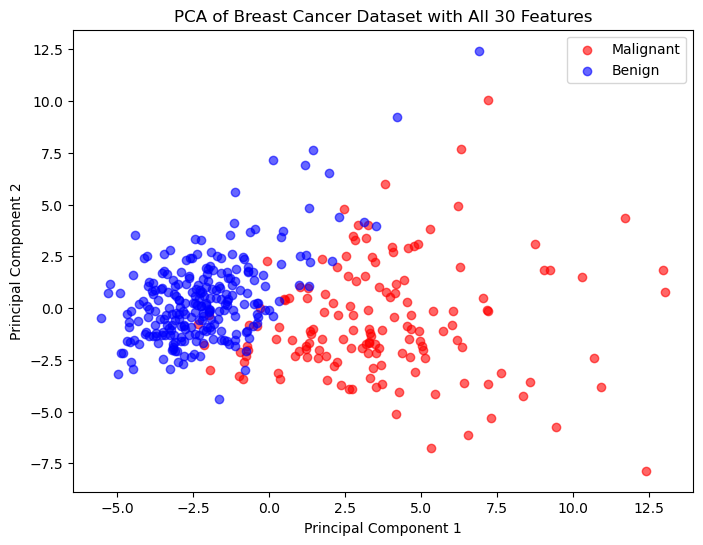

Explained variance ratio: [0.4369247  0.19226383]


In [10]:
scaler = StandardScaler()
X_train_stan = scaler.fit_transform(X_train)

X_scaled = X_train_stan


pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)


pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
pca_df['Diagnosis'] = y_train.values


plt.figure(figsize=(8,6))
plt.scatter(
    pca_df[pca_df['Diagnosis'] == 1]['PC1'],
    pca_df[pca_df['Diagnosis'] == 1]['PC2'],
    c='red', label='Malignant', alpha=0.6
)
plt.scatter(
    pca_df[pca_df['Diagnosis'] == 0]['PC1'],
    pca_df[pca_df['Diagnosis'] == 0]['PC2'],
    c='blue', label='Benign', alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Breast Cancer Dataset with All 30 Features")
plt.legend()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)



This PCA scatter plot shows the first two principal components extracted from the
standardized training data. Although PCA was
not used for modeling, it helps visualize the structure of the dataset.

We observe a clear separation between malignant and benign classes along the first
principal component. Malignant samples cluster tightly together and remain
distinct from benign samples, showing that the dataset has strong class separability.


In [11]:
X_val_stan = scaler.transform(X_val)
X_test_stan = scaler.transform(X_test)

In [12]:
X_train_stan.shape, X_val_stan.shape, X_test_stan.shape

((398, 30), (85, 30), (86, 30))

## Save the standardized splits to corresponding file path 
I saved the train/validation/test splits and the fitted StandardScaler so that preprocessing is done only once and the model construction notebook can load ready-to-use data without recalculating splits or scaling.

In [13]:
train_df = pd.DataFrame(X_train_stan, columns=X.columns)
train_df["Diagnosis"] = y_train.values
train_df.to_csv("../data/train/train.csv", index=False)


val_df = pd.DataFrame(X_val_stan, columns=X.columns)
val_df["Diagnosis"] = y_val.values
val_df.to_csv("../data/val/val.csv", index=False)


test_df = pd.DataFrame(X_test_stan, columns=X.columns)
test_df["Diagnosis"] = y_test.values
test_df.to_csv("../data/test/test.csv", index=False)


I saved the fitted scaler object for applying the same scaling transformating in model notebook and for any further new data in future.

In [14]:
import joblib

joblib.dump(scaler, "../data/scaler.pkl")

['../data/scaler.pkl']